In [1]:
import os
import time
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("========== TASK 10 SETUP ==========\n")

# Load the SAME controlled 20-step split used in Tasks 7–9
X_train = np.load(
    "X_train_20step_experiment.npy",
    mmap_mode="r"
)
y_train = np.load(
    "y_train_20step_experiment.npy",
    mmap_mode="r"
)

X_val = np.load(
    "X_val_20step_experiment.npy",
    mmap_mode="r"
)
y_val = np.load(
    "y_val_20step_experiment.npy",
    mmap_mode="r"
)

X_test = np.load(
    "X_test_20step_experiment.npy",
    mmap_mode="r"
)
y_test = np.load(
    "y_test_20step_experiment.npy",
    mmap_mode="r"
)

print("Sequence data:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

# ------------------------------------------------------------
# RF uses ONLY the final/current observation from each window
# ------------------------------------------------------------

X_train_rf = X_train[:, -1, :]
X_val_rf   = X_val[:, -1, :]
X_test_rf  = X_test[:, -1, :]

print("\nRF input data:")
print("Train:", X_train_rf.shape)
print("Val  :", X_val_rf.shape)
print("Test :", X_test_rf.shape)

# Basic checks
assert X_train_rf.shape[1] == 105
assert X_val_rf.shape[1] == 105
assert X_test_rf.shape[1] == 105

assert len(X_train_rf) == len(y_train)
assert len(X_val_rf) == len(y_val)
assert len(X_test_rf) == len(y_test)

print("\n✅ Task 10 setup complete")
print("RF input = final/current observation from each 20-step sequence")

========== TASK 10 SETUP ==========

Sequence data:
Train: (44795, 20, 105) (44795,)
Val  : (9810, 20, 105) (9810,)
Test : (9450, 20, 105) (9450,)

RF input data:
Train: (44795, 105)
Val  : (9810, 105)
Test : (9450, 105)

✅ Task 10 setup complete
RF input = final/current observation from each 20-step sequence


In [2]:
print("========== TRAINING RANDOM FOREST ==========\n")

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

start_time = time.time()

rf.fit(
    X_train_rf,
    y_train
)

rf_training_time = (
    time.time() - start_time
) / 60.0

# Validation predictions
rf_val_pred = rf.predict(X_val_rf)

# Test predictions
rf_test_pred = rf.predict(X_test_rf)

# Metrics
rf_val_mae = mean_absolute_error(
    y_val,
    rf_val_pred
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_pred
    )
)

rf_val_r2 = r2_score(
    y_val,
    rf_val_pred
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("========== RANDOM FOREST RESULTS ==========")

print("\nValidation:")
print(f"MAE  : {rf_val_mae:.4f}")
print(f"RMSE : {rf_val_rmse:.4f}")
print(f"R²   : {rf_val_r2:.4f}")

print("\nTest:")
print(f"MAE  : {rf_test_mae:.4f}")
print(f"RMSE : {rf_test_rmse:.4f}")
print(f"R²   : {rf_test_r2:.4f}")

print(f"\nTraining time: {rf_training_time:.2f} min")

# Save predictions
pd.DataFrame({
    "actual_rul": y_test,
    "rf_predicted_rul": rf_test_pred
}).to_csv(
    "TASK10_rf_20step_controlled_predictions.csv",
    index=False
)

print("\nSaved: TASK10_rf_20step_controlled_predictions.csv")

========== TRAINING RANDOM FOREST ==========

========== RANDOM FOREST RESULTS ==========

Validation:
MAE  : 44.7836
RMSE : 60.0229
R²   : 0.2807

Test:
MAE  : 40.7251
RMSE : 51.7841
R²   : 0.3927

Training time: 0.22 min

Saved: TASK10_rf_20step_controlled_predictions.csv


In [3]:
# LSTM seed-42 result from locked Task 8
lstm_mae = 44.143620
lstm_rmse = 58.884875
lstm_r2 = 0.214766

# RF result from the SAME controlled split
comparison_df = pd.DataFrame({
    "Model": [
        "LSTM (20-step, seed 42)",
        "Random Forest (current observation)"
    ],
    "MAE": [
        lstm_mae,
        rf_test_mae
    ],
    "RMSE": [
        lstm_rmse,
        rf_test_rmse
    ],
    "R2": [
        lstm_r2,
        rf_test_r2
    ]
})

print("========== FAIR RF vs LSTM COMPARISON ==========\n")
display(comparison_df)

comparison_df.to_csv(
    "TASK10_RF_vs_LSTM_controlled_comparison.csv",
    index=False
)

print("Saved: TASK10_RF_vs_LSTM_controlled_comparison.csv")

========== FAIR RF vs LSTM COMPARISON ==========



,Model,MAE,RMSE,R2
0,"LSTM (20-step, seed 42)",44.143620,58.884875,0.214766
1,Random Forest (current observation),40.725099,51.784124,0.392726


Saved: TASK10_RF_vs_LSTM_controlled_comparison.csv


========== LSTM CONVERGENCE ANALYSIS ==========

Seeds found: [np.int64(42), np.int64(123), np.int64(2024)]
Total history rows: 19


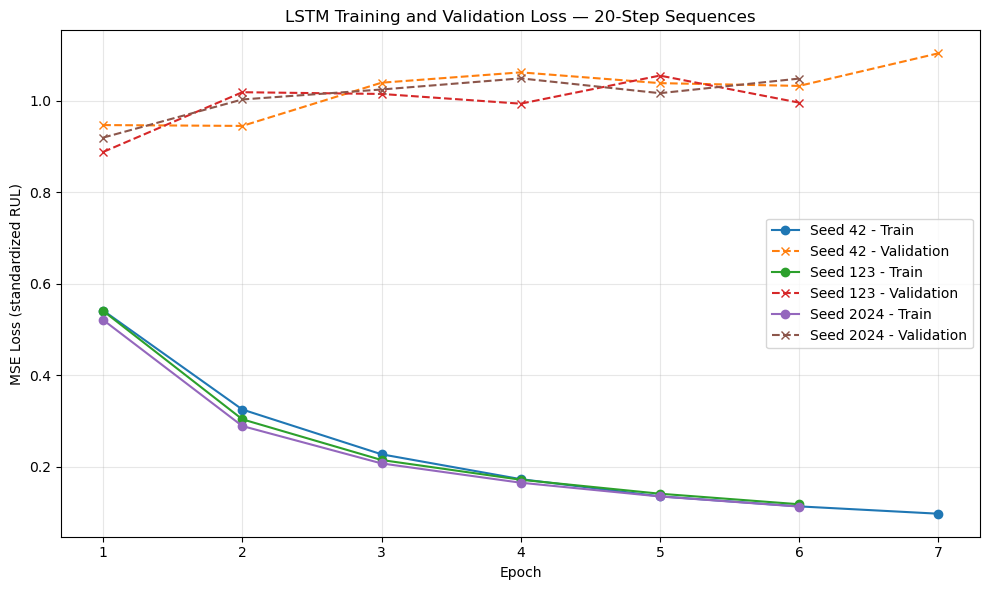


Saved: TASK10_LSTM_training_validation_loss.png


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Task 8 training histories
history_df = pd.read_csv(
    "TASK8_three_seed_training_histories.csv"
)

print("========== LSTM CONVERGENCE ANALYSIS ==========\n")
print("Seeds found:", sorted(history_df["seed"].unique()))
print("Total history rows:", len(history_df))

# ------------------------------------------------------------
# Training vs validation loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

for seed in sorted(history_df["seed"].unique()):

    seed_data = history_df[
        history_df["seed"] == seed
    ]

    plt.plot(
        seed_data["epoch"],
        seed_data["train_loss"],
        marker="o",
        label=f"Seed {seed} - Train"
    )

    plt.plot(
        seed_data["epoch"],
        seed_data["val_loss"],
        marker="x",
        linestyle="--",
        label=f"Seed {seed} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("MSE Loss (standardized RUL)")
plt.title("LSTM Training and Validation Loss — 20-Step Sequences")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "TASK10_LSTM_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved: TASK10_LSTM_training_validation_loss.png")

In [5]:
# Convergence summary for each seed

convergence_rows = []

for seed in sorted(history_df["seed"].unique()):

    seed_data = history_df[
        history_df["seed"] == seed
    ].copy()

    # Epoch with lowest validation loss
    best_row = seed_data.loc[
        seed_data["val_loss"].idxmin()
    ]

    # Final recorded epoch
    final_row = seed_data.iloc[-1]

    convergence_rows.append({
        "Seed": int(seed),
        "Best_Epoch": int(best_row["epoch"]),
        "Best_Val_Loss": best_row["val_loss"],
        "Train_Loss_at_Best_Epoch": best_row["train_loss"],
        "Final_Epoch": int(final_row["epoch"]),
        "Final_Train_Loss": final_row["train_loss"],
        "Final_Val_Loss": final_row["val_loss"],
        "Generalization_Gap_at_Best": (
            best_row["val_loss"] - best_row["train_loss"]
        )
    })

convergence_df = pd.DataFrame(convergence_rows)

print("========== LSTM CONVERGENCE SUMMARY ==========\n")
display(convergence_df)

convergence_df.to_csv(
    "TASK10_LSTM_convergence_summary.csv",
    index=False
)

print("Saved: TASK10_LSTM_convergence_summary.csv")

========== LSTM CONVERGENCE SUMMARY ==========



,Seed,Best_Epoch,Best_Val_Loss,Train_Loss_at_Best_Epoch,Final_Epoch,Final_Train_Loss,Final_Val_Loss,Generalization_Gap_at_Best
0,42,2,0.944707,0.325439,7,0.097970,1.103161,0.619268
1,123,1,0.887846,0.540663,6,0.118615,0.995563,0.347183
2,2024,1,0.919179,0.521013,6,0.113492,1.048056,0.398166


Saved: TASK10_LSTM_convergence_summary.csv


In [7]:
# Final controlled comparison
rf_vs_lstm = comparison_df.copy()

# Calculate RF advantage over LSTM
lstm_row = rf_vs_lstm[
    rf_vs_lstm["Model"].str.contains("LSTM")
].iloc[0]

rf_row = rf_vs_lstm[
    rf_vs_lstm["Model"].str.contains("Random Forest")
].iloc[0]

summary_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "LSTM_20step_seed42": [
        lstm_row["MAE"],
        lstm_row["RMSE"],
        lstm_row["R2"]
    ],
    "Random_Forest": [
        rf_row["MAE"],
        rf_row["RMSE"],
        rf_row["R2"]
    ]
})

summary_metrics["RF_minus_LSTM"] = (
    summary_metrics["Random_Forest"]
    - summary_metrics["LSTM_20step_seed42"]
)

print("========== TASK 10 FINAL MODEL COMPARISON ==========\n")
display(summary_metrics)

# Save
summary_metrics.to_csv(
    "TASK10_final_model_comparison.csv",
    index=False
)

# Save convergence summary together with comparison
print("\n========== CONVERGENCE SUMMARY ==========\n")
display(convergence_df)

print("\nSaved: TASK10_final_model_comparison.csv")
print("Saved: TASK10_LSTM_convergence_summary.csv")

========== TASK 10 FINAL MODEL COMPARISON ==========



,Metric,LSTM_20step_seed42,Random_Forest,RF_minus_LSTM
0,MAE,44.143620,40.725099,-3.418521
1,RMSE,58.884875,51.784124,-7.100751
2,R2,0.214766,0.392726,0.177960



========== CONVERGENCE SUMMARY ==========



,Seed,Best_Epoch,Best_Val_Loss,Train_Loss_at_Best_Epoch,Final_Epoch,Final_Train_Loss,Final_Val_Loss,Generalization_Gap_at_Best
0,42,2,0.944707,0.325439,7,0.097970,1.103161,0.619268
1,123,1,0.887846,0.540663,6,0.118615,0.995563,0.347183
2,2024,1,0.919179,0.521013,6,0.113492,1.048056,0.398166



Saved: TASK10_final_model_comparison.csv
Saved: TASK10_LSTM_convergence_summary.csv


In [8]:
task10_notes = pd.DataFrame({
    "Finding": [
        "Random Forest vs LSTM",
        "RF MAE advantage",
        "RF RMSE advantage",
        "RF R2 advantage",
        "LSTM convergence",
        "Possible reason 1",
        "Possible reason 2",
        "Possible reason 3",
        "Censoring limitation"
    ],
    "Observation": [
        "Random Forest performs better than the 20-step LSTM on the same controlled split.",
        "RF reduces MAE by 3.42 RUL time steps compared with LSTM.",
        "RF reduces RMSE by 7.10 RUL time steps compared with LSTM.",
        "RF R2 is higher by 0.178 compared with LSTM.",
        "Training loss decreases continuously while validation loss stops improving after approximately 1–2 epochs.",
        "The current sensor observation may already contain strong predictive information, so temporal history may add limited useful information.",
        "Random Forest is well suited to nonlinear relationships and feature interactions in structured tabular sensor data.",
        "The current LSTM configuration may not generalize well; the large train-validation gap indicates overfitting or model-data mismatch.",
        "Only vehicles with observed repair events provide exact RUL labels; censored vehicles cannot be assigned exact RUL without additional assumptions."
    ]
})

task10_notes.to_csv(
    "TASK10_research_findings_and_limitations.csv",
    index=False
)

print("Saved: TASK10_research_findings_and_limitations.csv")
display(task10_notes)

Saved: TASK10_research_findings_and_limitations.csv


,Finding,Observation
0,Random Forest vs LSTM,Random Forest performs better than the 20-step...
1,RF MAE advantage,RF reduces MAE by 3.42 RUL time steps compared...
2,RF RMSE advantage,RF reduces RMSE by 7.10 RUL time steps compare...
3,RF R2 advantage,RF R2 is higher by 0.178 compared with LSTM.
4,LSTM convergence,Training loss decreases continuously while val...
5,Possible reason 1,The current sensor observation may already con...
6,Possible reason 2,Random Forest is well suited to nonlinear rela...
7,Possible reason 3,The current LSTM configuration may not general...
8,Censoring limitation,Only vehicles with observed repair events prov...


In [9]:
import os
import pandas as pd

print("========== TASK 10 FINAL CHECK ==========\n")

# 1. Model comparison
comparison = pd.read_csv(
    "TASK10_final_model_comparison.csv"
)

print("RF vs LSTM:")
display(comparison)

assert len(comparison) == 3
assert comparison["Metric"].tolist() == ["MAE", "RMSE", "R2"]

print("Model comparison check: PASS")

# 2. Convergence summary
convergence = pd.read_csv(
    "TASK10_LSTM_convergence_summary.csv"
)

print("\nConvergence summary:")
display(convergence)

assert len(convergence) == 3
assert convergence["Seed"].tolist() == [42, 123, 2024]

print("Convergence check: PASS")

# 3. Research findings
findings = pd.read_csv(
    "TASK10_research_findings_and_limitations.csv"
)

assert len(findings) == 9

print("\nResearch findings check: PASS")

# 4. Required files
required_files = [
    "TASK10_rf_20step_controlled_predictions.csv",
    "TASK10_RF_vs_LSTM_controlled_comparison.csv",
    "TASK10_final_model_comparison.csv",
    "TASK10_LSTM_training_validation_loss.png",
    "TASK10_LSTM_convergence_summary.csv",
    "TASK10_research_findings_and_limitations.csv"
]

print("\nFile check:")

for f in required_files:
    status = "PASS" if os.path.exists(f) else "MISSING"
    print(f"{f}: {status}")
    assert os.path.exists(f)

print("\n✅ TASK 10 LOCKED SUCCESSFULLY")

========== TASK 10 FINAL CHECK ==========

RF vs LSTM:


,Metric,LSTM_20step_seed42,Random_Forest,RF_minus_LSTM
0,MAE,44.143620,40.725099,-3.418521
1,RMSE,58.884875,51.784124,-7.100751
2,R2,0.214766,0.392726,0.177960


Model comparison check: PASS

Convergence summary:


,Seed,Best_Epoch,Best_Val_Loss,Train_Loss_at_Best_Epoch,Final_Epoch,Final_Train_Loss,Final_Val_Loss,Generalization_Gap_at_Best
0,42,2,0.944707,0.325439,7,0.097970,1.103161,0.619268
1,123,1,0.887846,0.540663,6,0.118615,0.995563,0.347183
2,2024,1,0.919179,0.521013,6,0.113492,1.048056,0.398166


Convergence check: PASS

Research findings check: PASS

File check:
TASK10_rf_20step_controlled_predictions.csv: PASS
TASK10_RF_vs_LSTM_controlled_comparison.csv: PASS
TASK10_final_model_comparison.csv: PASS
TASK10_LSTM_training_validation_loss.png: PASS
TASK10_LSTM_convergence_summary.csv: PASS
TASK10_research_findings_and_limitations.csv: PASS

✅ TASK 10 LOCKED SUCCESSFULLY


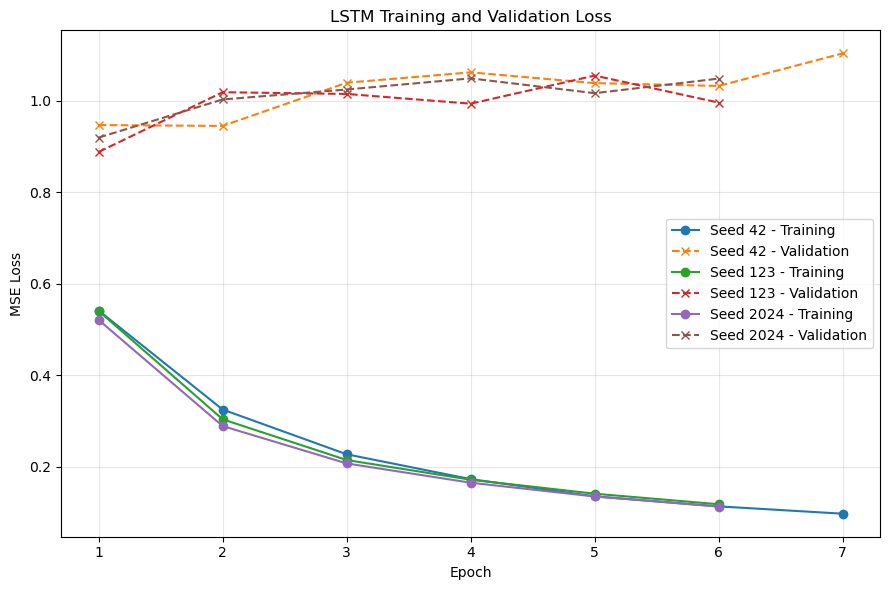

Saved: TASK10_LSTM_training_validation_loss.png


In [10]:
# ============================================================
# TASK 10 — SAVE LSTM TRAINING / VALIDATION LOSS CURVES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for seed in sorted(history_df["seed"].unique()):

    seed_data = history_df[
        history_df["seed"] == seed
    ].sort_values("epoch")

    plt.plot(
        seed_data["epoch"],
        seed_data["train_loss"],
        marker="o",
        label=f"Seed {seed} - Training"
    )

    plt.plot(
        seed_data["epoch"],
        seed_data["val_loss"],
        marker="x",
        linestyle="--",
        label=f"Seed {seed} - Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "TASK10_LSTM_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: TASK10_LSTM_training_validation_loss.png")

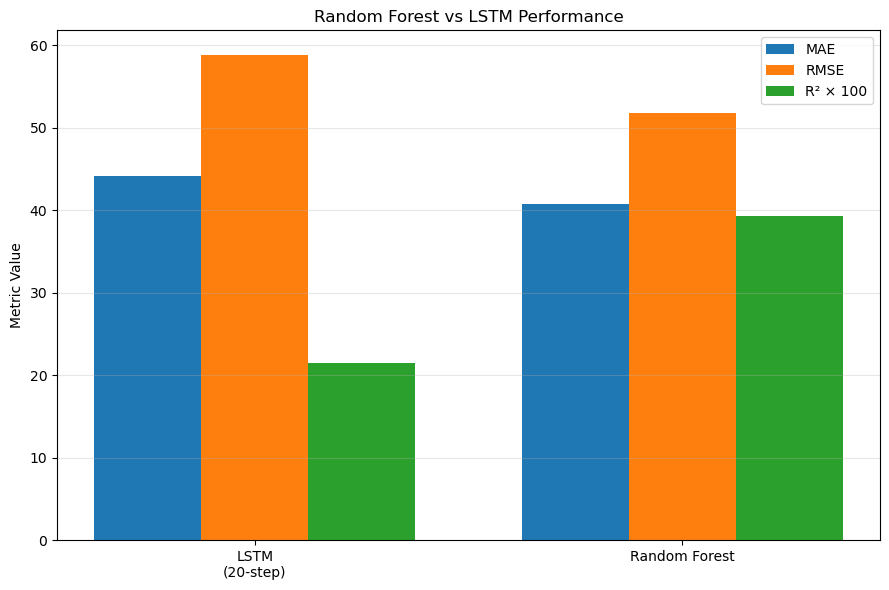

Saved: TASK10_RF_vs_LSTM_comparison.png


In [11]:
# ============================================================
# TASK 10 — SAVE RANDOM FOREST VS LSTM COMPARISON FIGURE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = ["LSTM\n(20-step)", "Random Forest"]

mae = [44.143620, 40.725099]
rmse = [58.884875, 51.784124]
r2 = [0.214766, 0.392726]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9, 6))

plt.bar(x - width, mae, width, label="MAE")
plt.bar(x, rmse, width, label="RMSE")
plt.bar(x + width, [r * 100 for r in r2],
        width, label="R² × 100")

plt.xticks(x, models)
plt.ylabel("Metric Value")
plt.title("Random Forest vs LSTM Performance")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "TASK10_RF_vs_LSTM_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: TASK10_RF_vs_LSTM_comparison.png")